In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


In [17]:
# Step 1: Inspect dataset structure
import os, textwrap

DATA_DIR = "/kaggle/input/gtsrb-german-traffic-sign"
print("DATA_DIR:", DATA_DIR)
print("\nTop-level entries:")
for name in sorted(os.listdir(DATA_DIR)):
    print(" -", name)

# Show subtree (two levels) to help locate train/test images
print("\nSample subtree (up to 2 levels):")
for entry in sorted(os.listdir(DATA_DIR)):
    p = os.path.join(DATA_DIR, entry)
    if os.path.isdir(p):
        sub = sorted(os.listdir(p))[:20]
        print(f"\n{entry}/ -> {len(sub)} entries (showing up to 20):")
        if sub:
            print(textwrap.fill(", ".join(sub[:20]), width=120))


DATA_DIR: /kaggle/input/gtsrb-german-traffic-sign

Top-level entries:
 - Meta
 - Meta.csv
 - Test
 - Test.csv
 - Train
 - Train.csv
 - meta
 - test
 - train

Sample subtree (up to 2 levels):

Meta/ -> 20 entries (showing up to 20):
.~lock.ClassesInformation.ods#, .~lock.ClassesInformationStrong.ods#, 0.png, 1.png, 10.png, 11.png, 12.png, 13.png,
14.png, 15.png, 16.png, 17.png, 18.png, 19.png, 2.png, 20.png, 21.png, 22.png, 23.png, 24.png

Test/ -> 20 entries (showing up to 20):
00000.png, 00001.png, 00002.png, 00003.png, 00004.png, 00005.png, 00006.png, 00007.png, 00008.png, 00009.png, 00010.png,
00011.png, 00012.png, 00013.png, 00014.png, 00015.png, 00016.png, 00017.png, 00018.png, 00019.png

Train/ -> 20 entries (showing up to 20):
0, 1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 20, 21, 22, 23, 24, 25, 26

meta/ -> 20 entries (showing up to 20):
.~lock.ClassesInformation.ods#, .~lock.ClassesInformationStrong.ods#, 0.png, 1.png, 10.png, 11.png, 12.png, 13.png,
14.png, 15.png, 16.png,

In [18]:
import pandas as pd

# Path to the train CSV
train_csv_path = "/kaggle/input/gtsrb-german-traffic-sign/Train.csv"

# Load CSV
train_df = pd.read_csv(train_csv_path)

# Display info and first few rows
print("Shape of Train.csv:", train_df.shape)
print("\nColumns:", train_df.columns.tolist())
train_df.head()


Shape of Train.csv: (39209, 8)

Columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


Number of classes: 43

Samples per class:
 ClassId
0      210
1     2220
2     2250
3     1410
4     1980
5     1860
6      420
7     1440
8     1410
9     1470
10    2010
11    1320
12    2100
13    2160
14     780
15     630
16     420
17    1110
18    1200
19     210
20     360
21     330
22     390
23     510
24     270
25    1500
26     600
27     240
28     540
29     270
30     450
31     780
32     240
33     689
34     420
35    1200
36     390
37     210
38    2070
39     300
40     360
41     240
42     240
Name: count, dtype: int64


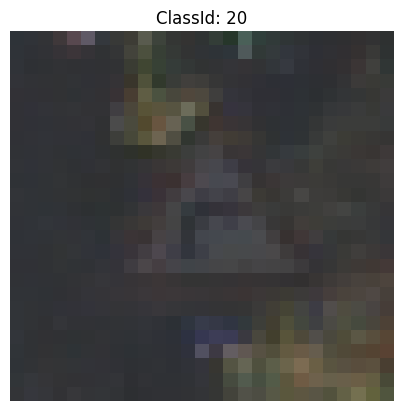

In [19]:
import os
import matplotlib.pyplot as plt
import cv2

# Number of unique classes
num_classes = train_df["ClassId"].nunique()
print("Number of classes:", num_classes)

# Distribution of samples per class
class_counts = train_df["ClassId"].value_counts().sort_index()
print("\nSamples per class:\n", class_counts)

# Show one sample image
sample_path = "/kaggle/input/gtsrb-german-traffic-sign/" + train_df.iloc[0]["Path"]
img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"ClassId: {train_df.iloc[0]['ClassId']}")
plt.axis("off")
plt.show()


In [20]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 32  # we can switch to 48 if needed

# Function to load and preprocess images
def preprocess_images(df, base_path):
    images = []
    labels = []
    
    for idx, row in df.iterrows():
        img_path = os.path.join(base_path, row["Path"])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(row["ClassId"])
    
    images = np.array(images, dtype="float32") / 255.0  # normalize
    labels = to_categorical(labels, num_classes=num_classes)
    return images, labels

# Load training data
X, y = preprocess_images(train_df, "/kaggle/input/gtsrb-german-traffic-sign")

print("X shape:", X.shape)
print("y shape:", y.shape)

# Split into train/validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)


X shape: (39209, 32, 32, 3)
y shape: (39209, 43)
Train set: (31367, 32, 32, 3) (31367, 43)
Validation set: (7842, 32, 32, 3) (7842, 43)


In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

# ❌ Do NOT call datagen.fit(X_train)


In [22]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64, shuffle=True),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


NameError: name 'model' is not defined

In [23]:
import numpy as np

print("y train sample (first 5):")
print(np.argmax(y_train[:5], axis=1))  # should give class indices (0–42)

print("Unique classes in y_train:", np.unique(np.argmax(y_train, axis=1)))
print("Number of unique classes:", len(np.unique(np.argmax(y_train, axis=1))))


y train sample (first 5):
[12 26 12 12  8]
Unique classes in y_train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]
Number of unique classes: 43


Sample 0 min/max: 0.003921569 1.0


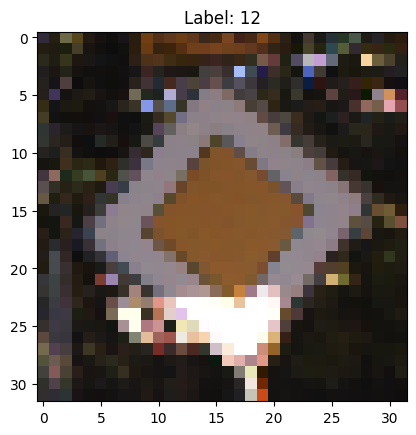

Sample 1 min/max: 0.1254902 1.0


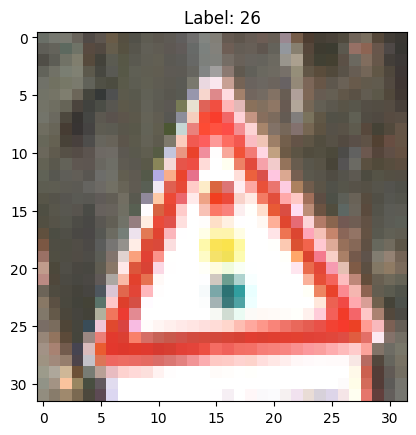

Sample 2 min/max: 0.043137256 0.4392157


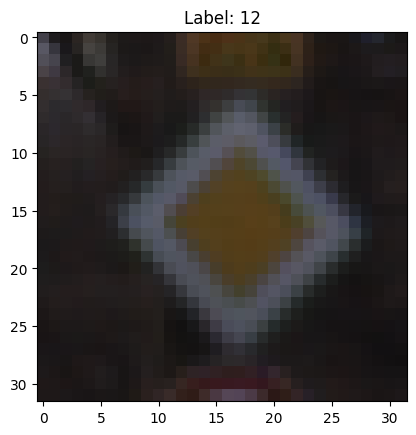

Sample 3 min/max: 0.08235294 1.0


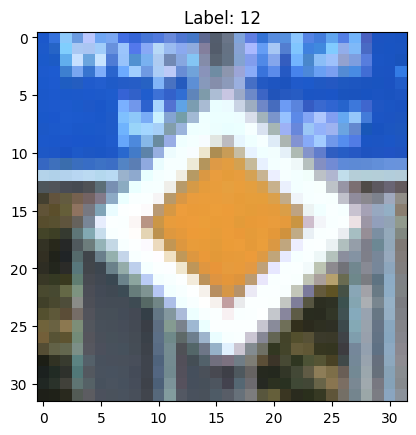

Sample 4 min/max: 0.023529412 0.9019608


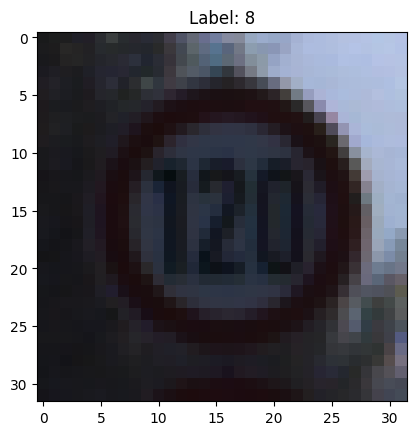

In [24]:
import matplotlib.pyplot as plt

for i in range(5):
    print(f"Sample {i} min/max:", X_train[i].min(), X_train[i].max())
    plt.imshow(X_train[i])
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.show()


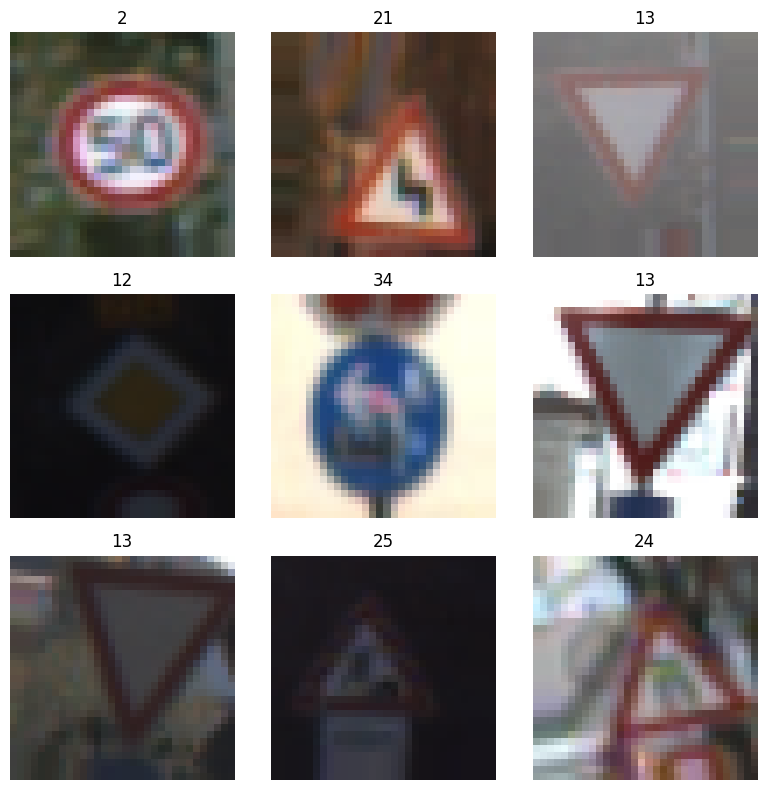

In [25]:
import matplotlib.pyplot as plt

x_batch, y_batch = next(datagen.flow(X_train, y_train, batch_size=9))

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(np.argmax(y_batch[i]))
    plt.axis('off')
plt.tight_layout()
plt.show()


In [26]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(43, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-08 12:47:06.256447: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,477,035 (17.08 MB)

 Trainable params: 4,477,035 (17.08 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Slightly higher learning rate and slower decay trigger
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0015)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-5)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=5,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


Epoch 1/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 256s 515ms/step - accuracy: 0.9450 - loss: 0.1782 - val_accuracy: 0.9926 - val_loss: 0.0262 - learning_rate: 0.0015
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 253s 516ms/step - accuracy: 0.9560 - loss: 0.1465 - val_accuracy: 0.9949 - val_loss: 0.0178 - learning_rate: 0.0015
Epoch 3/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 248s 505ms/step - accuracy: 0.9577 - loss: 0.1393 - val_accuracy: 0.9953 - val_loss: 0.0138 - learning_rate: 0.0015
Epoch 4/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 247s 502ms/step - accuracy: 0.9661 - loss: 0.1111 - val_accuracy: 0.9964 - val_loss: 0.0105 - learning_rate: 0.0015
Epoch 5/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 253s 514ms/step - accuracy: 0.9687 - loss: 0.1006 - val_accuracy: 0.9964 - val_loss: 0.0134 - learning_rate: 0.0015


In [28]:
import numpy as np
import tensorflow as tf

print("Number of trainable parameters:", np.sum([np.prod(v.shape) for v in model.trainable_weights]))
print("Model name:", model.name)
print("Number of layers:", len(model.layers))
model.summary()


Number of trainable parameters: 4477035
Model name: sequential
Number of layers: 12


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,477,035 (17.08 MB)

 Trainable params: 4,477,035 (17.08 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.save("traffic_sign_classifier.h5")


In [33]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=1)
print(f"Validation Accuracy: {val_acc*100:.2f}%")


246/246 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.9970 - loss: 0.0085
Validation Accuracy: 99.64%


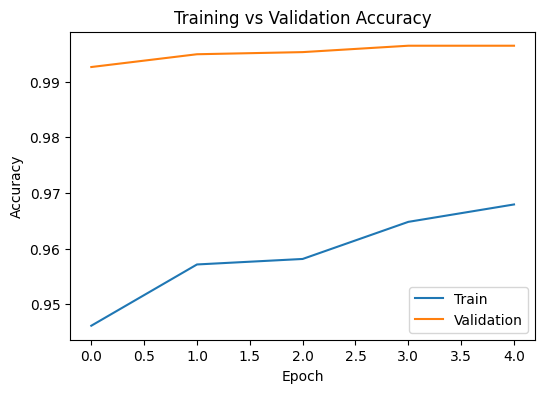

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


246/246 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      0.99      0.99       444
           2       0.99      0.99      0.99       450
           3       0.99      0.97      0.98       282
           4       0.99      1.00      0.99       396
           5       0.97      1.00      0.98       372
           6       1.00      1.00      1.00        84
           7       1.00      1.00      1.00       288
           8       1.00      1.00      1.00       282
           9       1.00      1.00      1.00       294
          10       1.00      1.00      1.00       402
          11       1.00      1.00      1.00       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       1.00      1.00      1.00       156
          15       1.00      0.98      0.99       126
          16       1.00      1.00     

<Axes: >

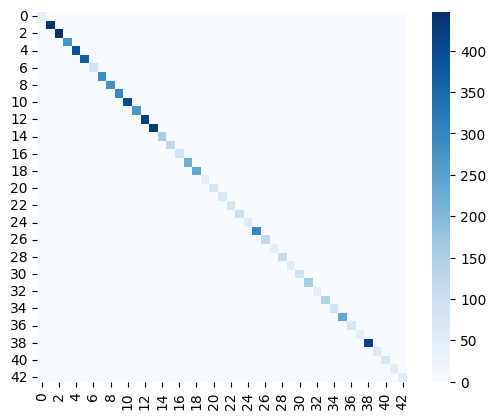

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

print(classification_report(y_true, y_pred_classes))

cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, cmap='Blues', square=True)
